In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
df = pd.read_csv("/Users/abhishekthale/Documents/project/netflix_titles.csv")

In [4]:
df.head()
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [5]:
df.size

105684

In [6]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [9]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [10]:
df["director"] = df["director"].fillna("unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Not Rated")

In [11]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64

In [12]:
df.dropna(inplace=True)

In [13]:
df["date_added"] = df["date_added"].str.strip()

In [14]:
df["date_added"] = df["date_added"].str.strip()

df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

In [15]:
df=df.dropna(subset=["date_added"])

In [16]:
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()

In [17]:
df.columns 

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added', 'month_added'],
      dtype='object')

In [18]:
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September


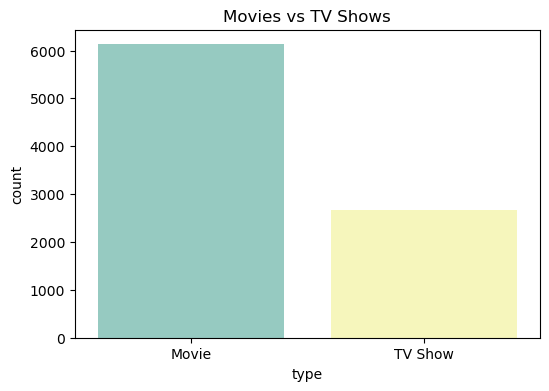

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="type" , palette="Set3")

plt.title("Movies vs TV Shows")
plt.show()

In [20]:
df["type"].value_counts()

# Netflix library is dominated by Movies compared to TV Shows.

type
Movie      6128
TV Show    2666
Name: count, dtype: int64

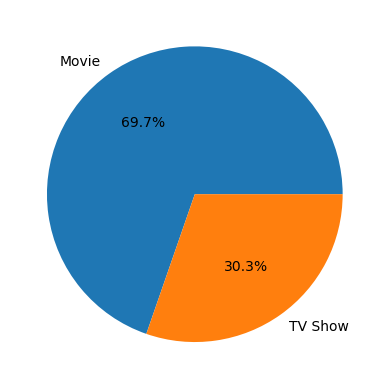

In [21]:
df["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.ylabel("")
plt.show()

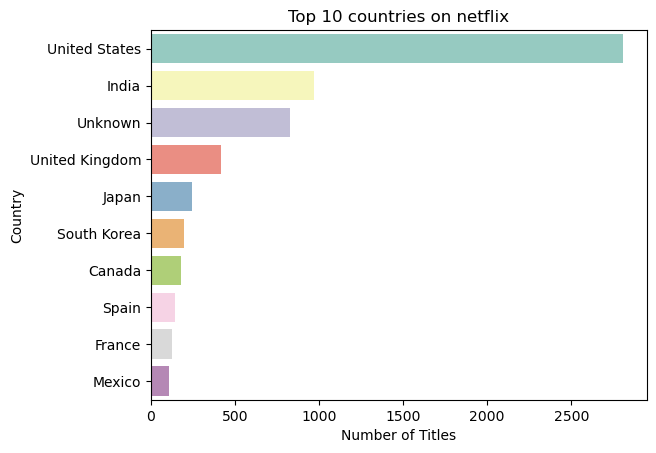

In [22]:
top_country = df["country"].value_counts().head(10)

sns.barplot(
    x=top_country.values,
    y=top_country.index,
    palette="Set3"
)

plt.xlabel("Number of Titles")
plt.title("Top 10 countries on netflix")
plt.ylabel("Country")

plt.show()

In [23]:
year_wise_content = df["year_added"].value_counts()

<Axes: xlabel='year_added'>

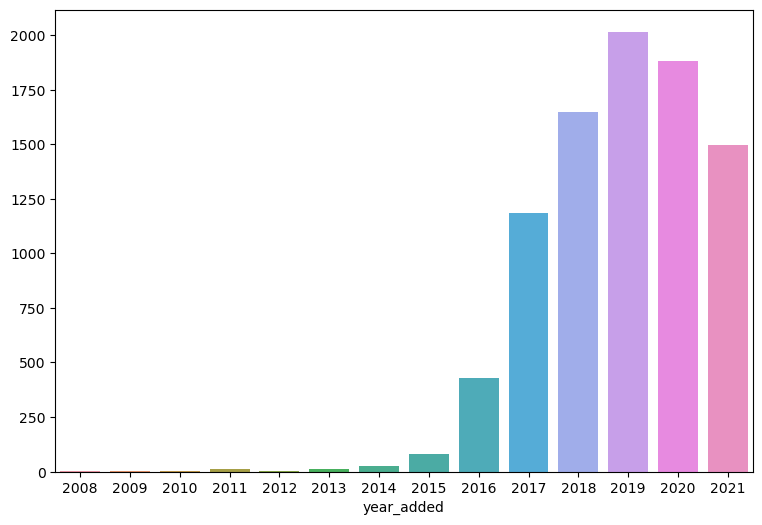

In [24]:

plt.figure(figsize=(9,6))
sns.barplot(
    x = year_wise_content.index,
    y = year_wise_content.values
)




# Which content ratings are most common on Netflix?

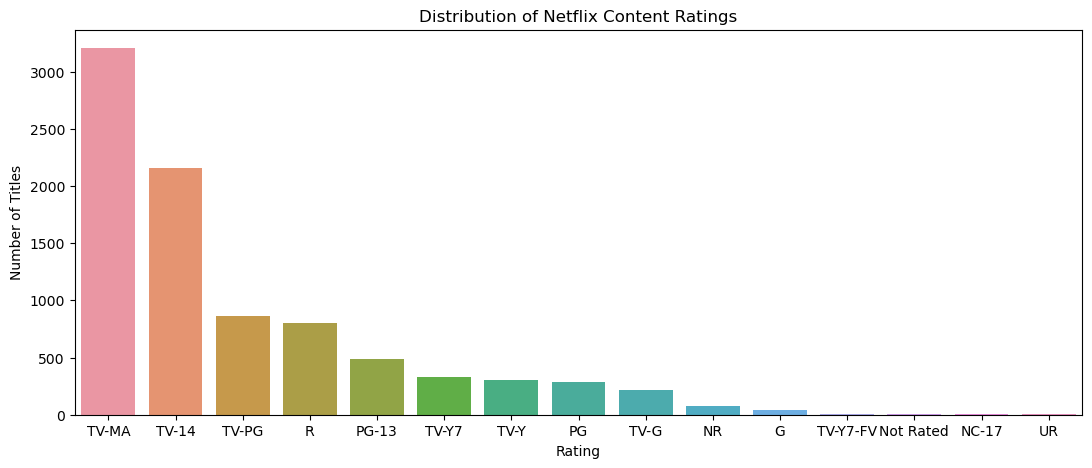

In [25]:
common_ratings = df["rating"].value_counts()

plt.figure(figsize=(13,5))

sns.barplot(
    x=common_ratings.index,
    y=common_ratings.values
)

plt.title("Distribution of Netflix Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=0)

plt.show()

In [26]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,September
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September
3,s4,TV Show,Jailbirds New Orleans,unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,September
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,September


In [27]:
df["listed_in"].head()

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
Name: listed_in, dtype: object

In [28]:
genres = df["listed_in"].str.split(", ")

genres.head()

0                                      [Documentaries]
1    [International TV Shows, TV Dramas, TV Mysteries]
2    [Crime TV Shows, International TV Shows, TV Ac...
3                             [Docuseries, Reality TV]
4    [International TV Shows, Romantic TV Shows, TV...
Name: listed_in, dtype: object

In [29]:
genres = genres.explode()

In [30]:
genres.head()

0             Documentaries
1    International TV Shows
1                 TV Dramas
1              TV Mysteries
2            Crime TV Shows
Name: listed_in, dtype: object

In [31]:
top_genres = genres.value_counts().head(10)
top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

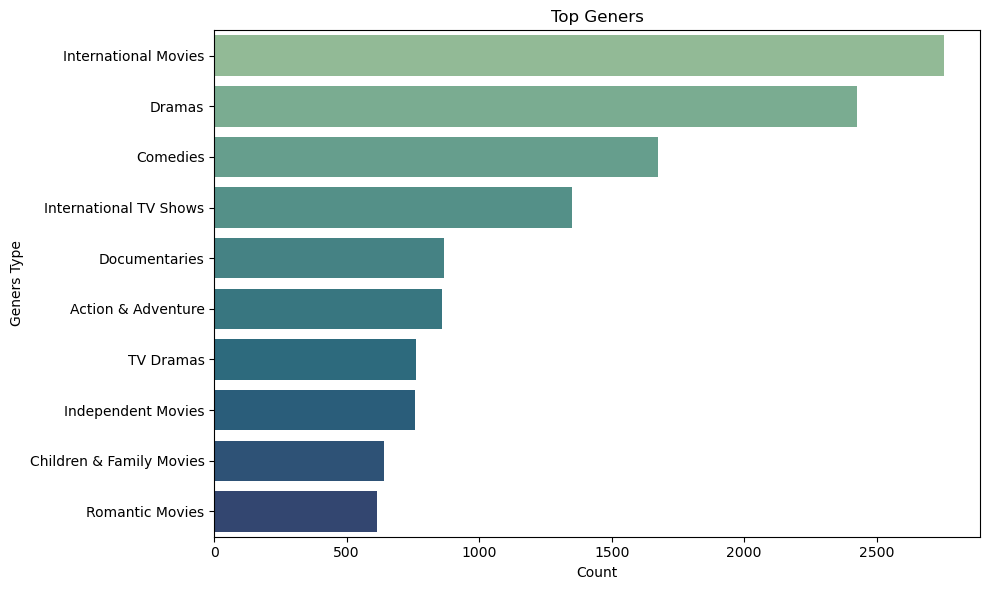

In [32]:
plt.figure(figsize=(10,6))

sns.barplot( 
    x= top_genres.values , 
    y = top_genres.index , 
    palette="crest" 
    
)

plt.title("Top Geners")
plt.ylabel("Geners Type")
plt.xlabel("Count")

plt.tight_layout()
plt.show()

### International Movies is the most common genre on Netflix with more than 2700 titles, followed by Dramas and Comedies. This indicates that Netflix focuses heavily on global and entertainment-driven content.

In [33]:
df[["type","listed_in"]].head()

,type,listed_in
0,Movie,Documentaries
1,TV Show,"International TV Shows, TV Dramas, TV Mysteries"
2,TV Show,"Crime TV Shows, International TV Shows, TV Act..."
3,TV Show,"Docuseries, Reality TV"
4,TV Show,"International TV Shows, Romantic TV Shows, TV ..."


In [34]:
genre_df = df.copy()

genre_df["listed_in"] = genre_df["listed_in"].str.split(", ")

genre_df = genre_df.explode("listed_in")

In [35]:
genre_df[["type","listed_in"]].head()

,type,listed_in
0,Movie,Documentaries
1,TV Show,International TV Shows
1,TV Show,TV Dramas
1,TV Show,TV Mysteries
2,TV Show,Crime TV Shows


In [36]:
pd.crosstab(
    genre_df["listed_in"],
    genre_df["type"]
)

type,Movie,TV Show
listed_in,,
Action & Adventure,859,0
Anime Features,71,0
Anime Series,0,175
British TV Shows,0,252
Children & Family Movies,641,0
Classic & Cult TV,0,26
Classic Movies,116,0
Comedies,1674,0
Crime TV Shows,0,469


In [37]:
genre_type = pd.crosstab(
    genre_df["listed_in"],
    genre_df["type"]
)

In [38]:
genre_type["Total"] = ( genre_type["Movie"] + 
                       genre_type["TV Show"])

In [39]:
genre_type.head()

type,Movie,TV Show,Total
listed_in,,,
Action & Adventure,859,0,859
Anime Features,71,0,71
Anime Series,0,175,175
British TV Shows,0,252,252
Children & Family Movies,641,0,641


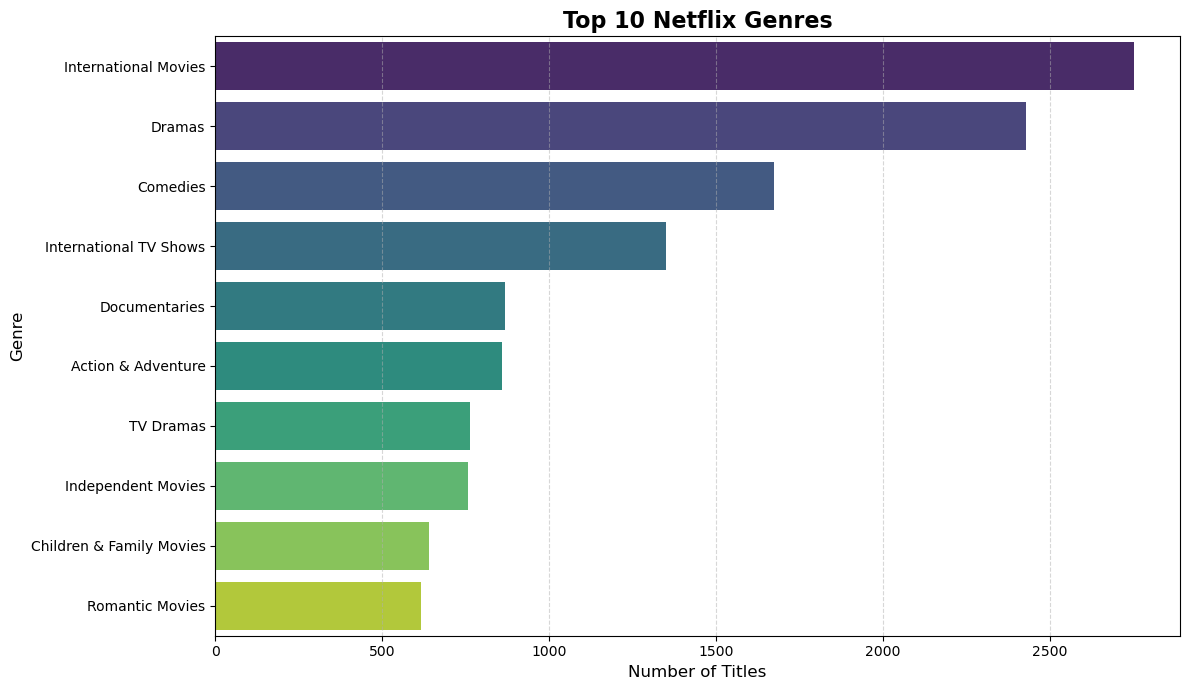

type,Movie,TV Show,Total
listed_in,,,
International Movies,2752,0,2752
Dramas,2427,0,2427
Comedies,1674,0,1674
International TV Shows,0,1350,1350
Documentaries,869,0,869
Action & Adventure,859,0,859
TV Dramas,0,762,762
Independent Movies,756,0,756
Children & Family Movies,641,0,641


In [40]:
top10 = genre_type.sort_values( 
    by= "Total" , 
    ascending=False
).head(10)

plt.figure(figsize=(12,7))

sns.barplot(
    x=top10["Total"],
    y=top10.index,
    palette="viridis"
)

plt.title(
    "Top 10 Netflix Genres",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Titles", fontsize=12)
plt.ylabel("Genre", fontsize=12)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()
top10

In [41]:
year_wise_content = (
    df["year_added"]
    .value_counts()
    .sort_index()
)

year_wise_content

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     427
2017    1187
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

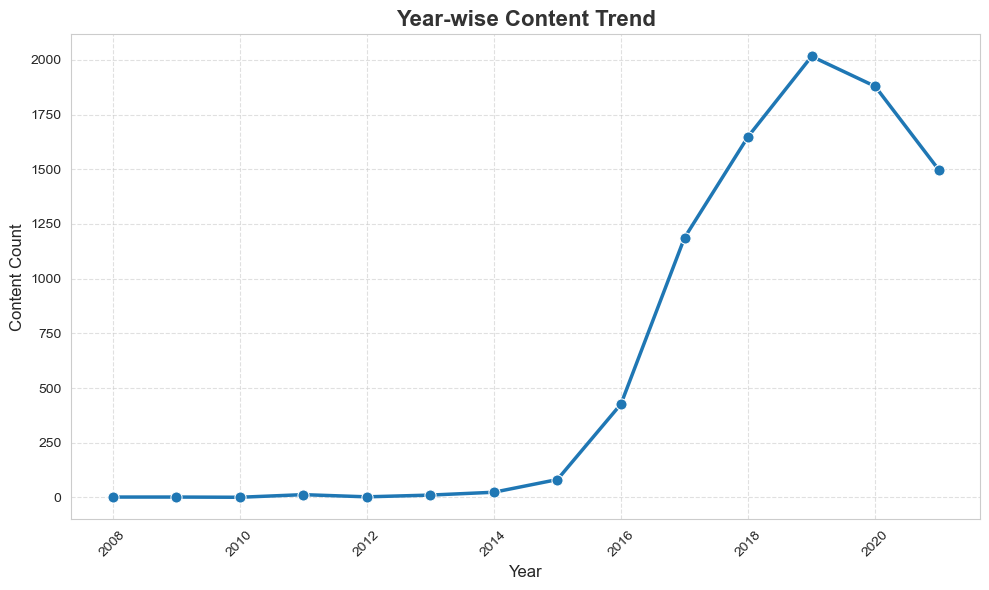

In [47]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")
sns.set_palette("coolwarm")

sns.lineplot(
    x=year_wise_content.index,
    y=year_wise_content.values,
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#1f77b4"
)

plt.title("Year-wise Content Trend", fontsize=16, fontweight="bold", color="#333333")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Content Count", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [64]:
heatmap_data = pd.crosstab(
    df["year_added"],
    df["month_added"]
)

In [65]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

heatmap_data = heatmap_data.reindex(
    columns=month_order
)

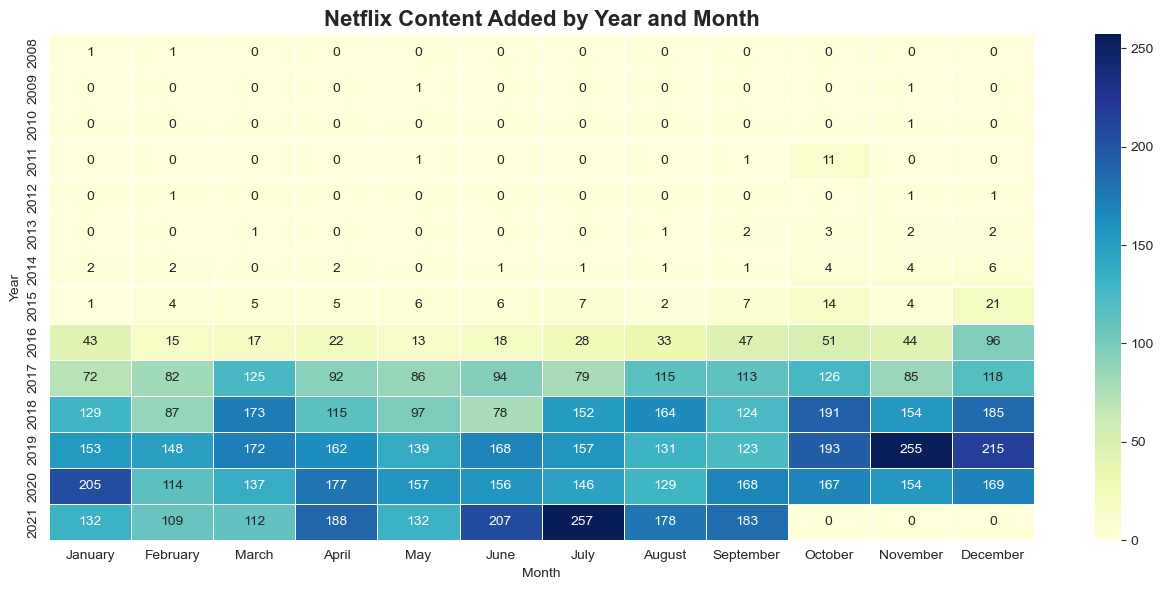

In [67]:
plt.figure(figsize=(13,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    annot=True,
    fmt="d"
)

plt.title(
    "Netflix Content Added by Year and Month",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Year")

plt.tight_layout()
plt.show()

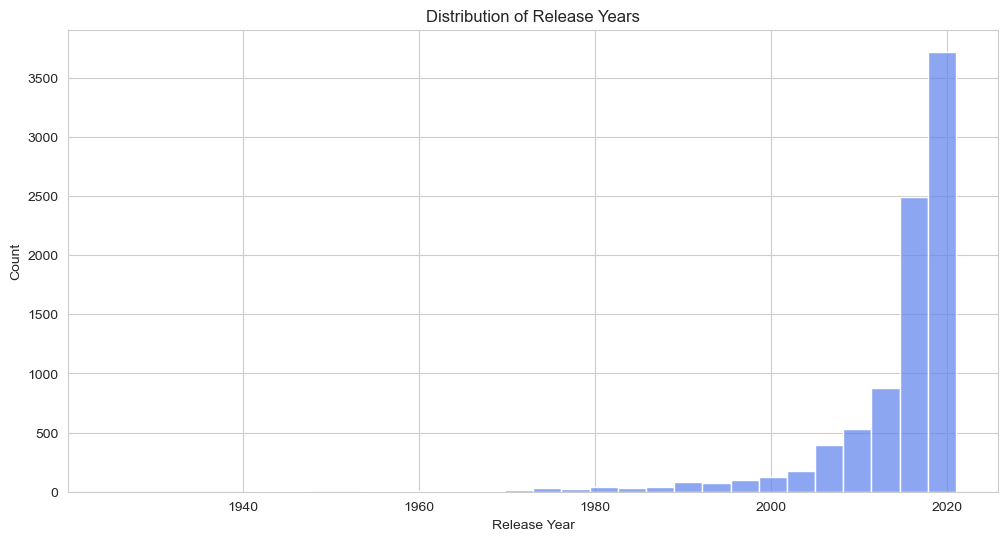

In [70]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="release_year",
    bins=30
)

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Count")

plt.show()

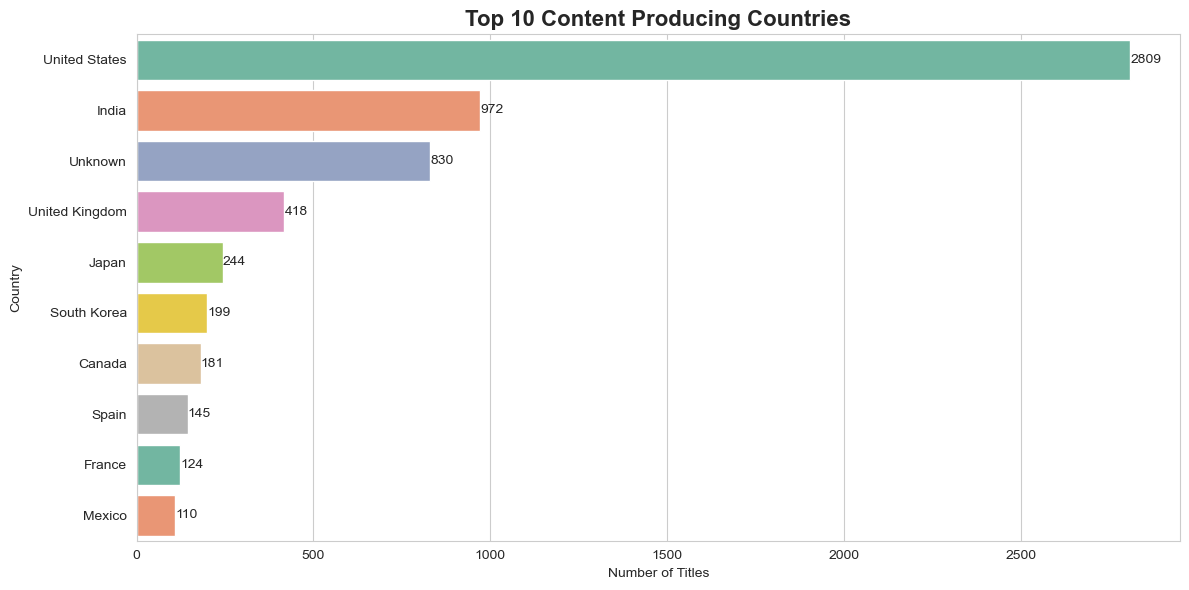

In [72]:
#Which countries contribute the most content to Netflix?
top_country = df["country"].value_counts().head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_country.values,
    y=top_country.index,
    palette="Set2"
)

for i in ax.containers:
    ax.bar_label(i)

plt.title(
    "Top 10 Content Producing Countries",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [73]:
df["country"].value_counts().head(10)

country
United States     2809
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

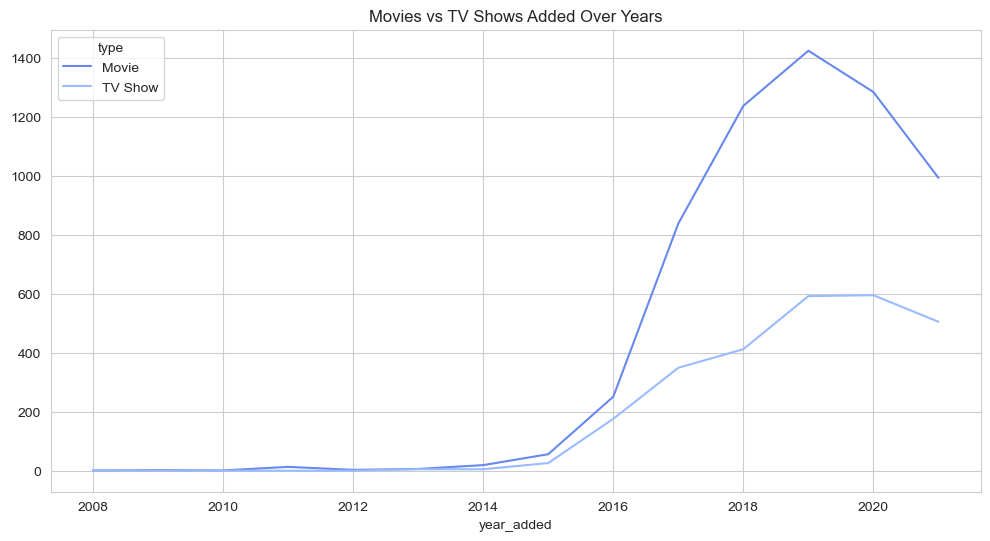

In [74]:
year_type = pd.crosstab(df["year_added"], df["type"])
year_type.plot(figsize=(12,6))
plt.title("Movies vs TV Shows Added Over Years")
plt.show()

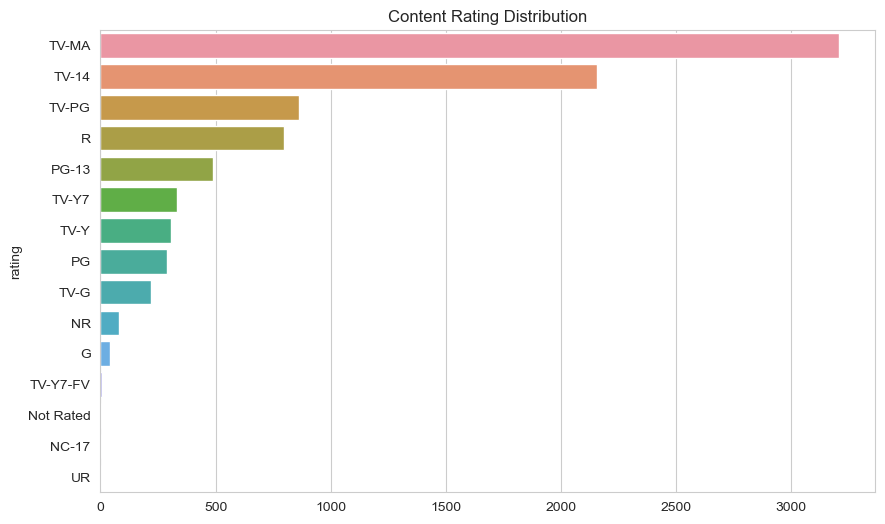

In [75]:
rating_counts = df["rating"].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(
    x=rating_counts.values,
    y=rating_counts.index
)
plt.title("Content Rating Distribution")
plt.show()

In [76]:
movies = df[df["type"]=="Movie"].copy()

movies["duration"] = movies["duration"].str.replace(" min","")
movies["duration"] = movies["duration"].astype(int)

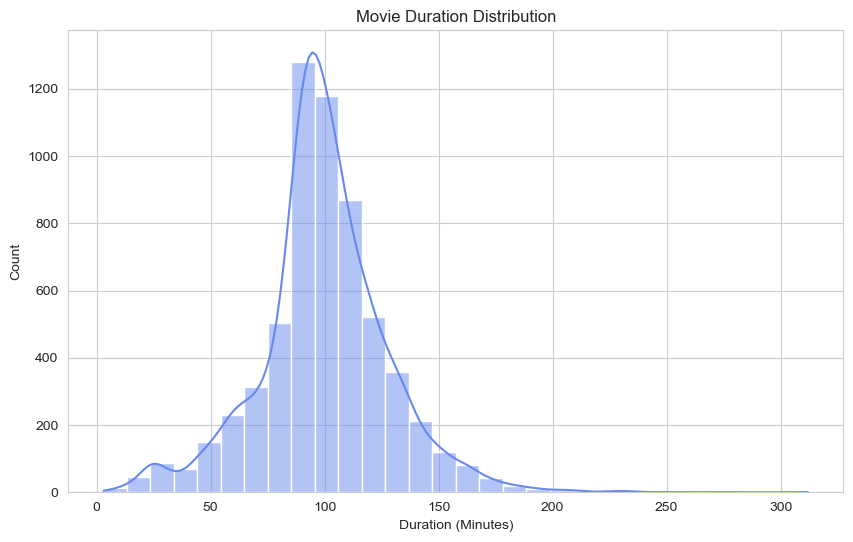

In [77]:
plt.figure(figsize=(10,6))

sns.histplot(
    movies["duration"],
    bins=30,
    kde=True
)

plt.title("Movie Duration Distribution")
plt.xlabel("Duration (Minutes)")
plt.show()